# Notebook 2 — the *unconditional verified range* of Firoozbakht's conjecture

**Run:** `germ-20260725-791a7c45` · **leg:** `notebooks__2` · **molecule:** `task-20260725-09a7`
**Target:** `unconditional-verified-range` (target #2)

---

## The conjecture

$$\textbf{(F)}\qquad p_{n+1}^{1/(n+1)} \;<\; p_n^{1/n}\qquad\text{for all } n\ge 1 .$$

**Status in this notebook: OPEN.** `F` is neither assumed true nor assumed false.
Everything below is computation. *Computation corroborates or refutes; it never
constitutes the proof.* Where this notebook says **PROVEN** it means a finite
statement discharged by exhaustive exact arithmetic, or a lemma derived here in
full from a cited effective bound — never `F` itself.

## What "unconditional" is doing in the target name

Three different things get called "the verified range", and they are not the same claim:

| | claim | costs | what it rests on |
|---|---|---|---|
| **(a)** | every consecutive prime pair below $X$ was individually checked | $\tilde O(X)$ | a sieve, and floating-point discipline |
| **(b)** | no gap that *occurs* below $X$ can violate `F`, wherever it occurs | $O(\#\text{gap sizes})$ | an effective $\pi(x)$ bound + a **first-occurrence table** |
| **(c)** | `F` holds below $X$ *assuming* RH / Cramér / a gap conjecture | free | an unproved hypothesis |

Target #2 is (a)+(b) and explicitly **not** (c). Route (b) is the one that reaches
$2^{64}$ in the literature (concept card **L6**), and its analytic half is
re-derived from scratch here as **Lemma A**, so that the notebook does not have
to be believed on the strength of a citation.

## What this notebook establishes, and what it does not

**Establishes (in-run, reproducible by re-executing this file):**

1. `F` holds at every $n$ with $p_n < 10^{11}$ — exhaustive, with a two-tier
   float-screen / exact-arithmetic protocol that cannot silently pass.
2. An unconditional lemma $T_n \ge L(L-1.1)$ for $p_n \ge 60184$ ($L=\log p_n$),
   derived here from one L0-tier effective bound, and then *numerically
   falsification-tested* over the whole sieved range.
3. Its corollary: a gap of size $g$ can violate `F` only at a prime
   $p \le S(g) := \exp\!\big((1.1+\sqrt{1.21+4g})/2\big)$ — and, with the
   in-run first-occurrence table, that **every** gap size occurring below
   $10^{11}$ clears that bar, with the minimum safety factor reported explicitly.
4. An independent reproduction of the "$g<1920$" figure attached to the $2^{64}$
   frontier, from our own arithmetic.
5. As a by-product of (1): **P6′** — card **L15**'s undischarged pruning rule, the
   run's *"single most tractable open obligation"* — checked over four billion
   pairs instead of two hundred thousand, with its *margin* measured rather than
   just its exception count. The margin shrinks (§6b). That is the leg's one
   genuinely unexpected result.

**Does not establish:** the frontier of $2^{64}$ itself. That step needs a
first-occurrence gap table to $4\cdot10^{18}$ that this run does not possess
(card **L6**: `oliveira2014goldbach`, ledger tier L2_weak, **never opened**).
§7 states exactly which inequality that external table has to satisfy, so the
dependency is a named hole rather than a citation.

---
## 1 · Definitions, and the criterion that has no error term

Following the run's concept cards:

$$g_n := p_{n+1}-p_n,\qquad L_n := \log p_n,\qquad
T_n := p_n\big(p_n^{1/n}-1\big) = p_n\big(e^{L_n/n}-1\big)\quad(\textbf{D5})$$

$$\rho_n := g_n/T_n \quad(\textbf{D6}),\qquad c_n := g_n/L_n^2 \quad(\textbf{D7})$$

**D6 is a biconditional with no error term and no index restriction:**

$$\textbf{F fails at } n \iff \rho_n \ge 1 .$$

`c_n` is *not* a substitute: `T_n < L_n^2` off a finite exception set (card **L13**),
so `c_n ≥ 1` is sufficient for refutation but strictly harder to satisfy — a search
run on `c_n` can step over a genuine counterexample. `c_n` is computed below only
to exhibit that gap, never as the objective.

**The exact criterion.** Raising both sides of `(F)` to the power $n(n+1)$ turns it
into an integer comparison with no logarithms at all:

$$\textbf{(F) at } n \iff p_{n+1}^{\,n} < p_n^{\,n+1}.$$

This is the ground truth against which every floating-point verdict in this
notebook is calibrated.

In [1]:
import json, math, os, platform, sys, time
from decimal import Decimal
import numpy as np
import matplotlib.pyplot as plt

import fb_core as fb

print("python    ", sys.version.split()[0], "on", platform.platform())
print("numpy     ", np.__version__)
print("fb_core   ", fb.__file__)

# Scale at which THIS notebook runs on execution. The recorded deep runs
# (up to 1e11) are in deep-runs.json, produced by deep_run.py using the very
# same fb_core.scan. Raise this if you want the notebook itself to go deeper.
N_NOTEBOOK = 10**8

python     3.10.15 on macOS-26.5.2-arm64-arm-64bit
numpy      2.2.4
fb_core    /Users/eserie/galaxies/firoozbakht-cleanroom/.worktrees/task-20260725-09a7/attack/notebook-2/fb_core.py


In [2]:
# The exact criterion, and the three ways of deciding F at one index.
for (n, pn, pnext) in [(217, 1327, 1361), (30, 113, 127), (1319945, 20831323, 20831533)]:
    exact = fb.exact_verdict(pn, pnext, n) if n < 20_000 else "n too large"
    cert, margin = fb.certified_verdict(pn, pnext, n)
    print(f"n={n:<9d} p_n={pn:<10d} g={pnext-pn:<4d} "
          f"rho={fb.rho(pn, pnext, n):.7f}  exact={exact}  certified={cert}")

n=217       p_n=1327       g=34   rho=0.7604709  exact=True  certified=True
n=30        p_n=113        g=14   rho=0.7259094  exact=True  certified=True
n=1319945   p_n=20831323   g=210  rho=0.7895959  exact=n too large  certified=True


In [3]:
# Calibration: exact integer comparison vs the Decimal-certified verdict,
# for EVERY n up to NCAL. If these ever disagree, the certified path is wrong
# and nothing downstream may be believed. NCAL is capped by the cost of the
# exact side: p_n^(n+1) has ~n*log10(p_n) digits, so this grows fast.
t0 = time.time()
pr = np.concatenate(list(fb.sieve_segments(230_000)))
NCAL = 5_000
disagree = []
for i in range(NCAL):
    n = i + 1
    e = fb.exact_verdict(int(pr[i]), int(pr[i+1]), n)
    c, _ = fb.certified_verdict(int(pr[i]), int(pr[i+1]), n)
    if e != c:
        disagree.append(n)
print(f"calibrated n = 1..{NCAL} (p_n up to {pr[NCAL-1]:,}) in {time.time()-t0:.1f}s")
print("disagreements between exact integer and Decimal-certified verdicts:", disagree)
print("F holds at every one of those indices:", all(
    fb.exact_verdict(int(pr[i]), int(pr[i+1]), i+1) for i in range(NCAL)))
assert not disagree

calibrated n = 1..5000 (p_n up to 48,611) in 1.8s
disagreements between exact integer and Decimal-certified verdicts: []


F holds at every one of those indices: True


---
## 2 · Direct exhaustive verification — route (a)

A segmented sieve, then $\rho_n$ for every consecutive pair. Two-tier by design:

* **screen** — float64 over all pairs. $\rho_n$ has $O(1)$ operands, so it does not
  carry the cancellation that destroys the "F2 margin" statistic (§3).
* **escalation** — every pair with $\rho_n \ge 0.90$ is re-decided in Decimal with an
  explicit error budget, and `certified_verdict` *raises* rather than returns if the
  margin lands inside that budget. Card **T2** Rule 3 names the hazard precisely:
  a probe that breaks only on a detected violation reports "no counterexample" from
  pure noise, and the failure is silent **in the verification direction**.

In [4]:
res = fb.scan(N_NOTEBOOK)
print()
print(f"pairs checked      : {res['pairs']:,}")
print(f"violations (rho>=1): {res['violations']}")
print(f"escalations (>=0.9): {len(res['escalations'])}")
print(f"max rho (n>=10)    : {res['top'][0][0]:.7f} at n={res['top'][0][1]:,}, "
      f"p_n={res['top'][0][2]:,}, g={res['top'][0][3]}")
print(f"max c   (n>=10)    : {res['max_c'][0]:.7f} at p_n={res['max_c'][2]:,}")
print(f"largest gap        : {res['records'][-1][2]} at p={res['records'][-1][1]:,}")

N=100,000,000  primes=5,761,455  pairs=5,761,454  0.4s

pairs checked      : 5,761,454
violations (rho>=1): []
escalations (>=0.9): 2
max rho (n>=10)    : 0.7895959 at n=1,319,945, p_n=20,831,323, g=210
max c   (n>=10)    : 0.7394657 at p_n=20,831,323
largest gap        : 220 at p=47,326,693


In [5]:
# Every escalated pair, re-decided in certified arithmetic. These are the only
# pairs anywhere in range that come within 10% of the bar -- and both are tiny
# indices, which is exactly why cards D6/T2 quote max rho for n >= 10.
for (n, pn, g, r) in res["escalations"]:
    cert, margin = fb.certified_verdict(pn, pn + g, n)
    exact = fb.exact_verdict(pn, pn + g, n)
    print(f"n={n:<4d} p_n={pn:<6d} g={g:<3d} rho={r:.7f}  "
          f"certified F holds = {cert}   exact F holds = {exact}")

n=2    p_n=3      g=2   rho=0.9106836  certified F holds = True   exact F holds = True
n=4    p_n=7      g=4   rho=0.9119852  certified F holds = True   exact F holds = True


In [6]:
# Reproduction check against the figures already in the run (cards D6, T2, L7,
# computed by the `decompose` and `concept-cards` legs at N = 3e6). Independent
# code path; the numbers must agree to the last digit quoted.
r3 = fb.scan(3 * 10**6, verbose=False)
expect = {
    "max rho (n>=10)":       (r3["top"][0][0], 0.7604709, "card D6: 0.7604709 at n=217, p=1327, g=34"),
    "runner-up rho":         (r3["top"][1][0], 0.7590821, "card D6: 0.759 at n=149689, p=2010733, g=148"),
    "max c (n>=10)":         (r3["max_c"][0],  0.7025656, "card T2: 0.70257 at p=2010733"),
    "max F2 margin ratio":   (r3["max_f2"][0], 0.9999984, "decompose 5.1: 0.9999984"),
}
for k, (got, want, src) in expect.items():
    ok = abs(got - want) < 5e-7
    print(f"{'OK ' if ok else 'MISMATCH'} {k:<22s} got {got:.7f}  expected {want:.7f}   [{src}]")
    assert ok, k
print(f"\nn=217 p_n=1327: {r3['top'][0][2]}   n=149689 p_n=2010733: {r3['top'][1][2]}")
print("violations at N=3e6:", r3["violations"])

OK  max rho (n>=10)        got 0.7604709  expected 0.7604709   [card D6: 0.7604709 at n=217, p=1327, g=34]
OK  runner-up rho          got 0.7590821  expected 0.7590821   [card D6: 0.759 at n=149689, p=2010733, g=148]
OK  max c (n>=10)          got 0.7025656  expected 0.7025656   [card T2: 0.70257 at p=2010733]
OK  max F2 margin ratio    got 0.9999984  expected 0.9999984   [decompose 5.1: 0.9999984]

n=217 p_n=1327: 1327   n=149689 p_n=2010733: 2010733
violations at N=3e6: []


In [7]:
# The recorded deep runs (deep_run.py, same fb_core.scan, up to 1e11).
DEEP = json.load(open("deep-runs.json")) if os.path.exists("deep-runs.json") else {}
print(f"{'N':>14} {'primes':>15} {'max rho (n>=10)':>16} {'at p_n':>16} {'g':>5} "
      f"{'max gap':>8} {'viol':>5} {'sec':>7}")
for k in sorted(DEEP, key=int):
    d = DEEP[k]
    t = d["top"][0]
    print(f"{int(k):>14,} {d['n_primes']:>15,} {t[0]:>16.7f} {t[2]:>16,} {t[3]:>5} "
          f"{d['records'][-1][2]:>8} {len(d['violations']):>5} {d['seconds']:>7.1f}")

             N          primes  max rho (n>=10)           at p_n     g  max gap  viol     sec
    10,000,000         664,579        0.7604709            1,327    34      154     0     0.1
   100,000,000       5,761,455        0.7895959       20,831,323   210      220     0     0.7
 1,000,000,000      50,847,534        0.7895959       20,831,323   210      282     0    12.4
10,000,000,000     455,052,511        0.7895959       20,831,323   210      354     0    91.7
100,000,000,000   4,118,054,813        0.8317570   25,056,082,087   456      464     0   881.6


**Read this table for what it is.** The record $\rho$ sits still for three
decades — $0.7896$ at $g=210$, $p=20\,831\,323$, unchanged from $10^8$ through
$10^{10}$ — and then moves once, at $10^{11}$, to $0.8318$ at the maximal gap
$g=456$, $p=25\,056\,082\,087$. Card **T2** is still right that a sieve in this
run cannot reach the interesting region: the published record ($\rho=0.94846$ at
$p=1.693\cdot10^{15}$, card **L7**) is 4.2 decades above $10^{11}$. But the
picture "extending the sieve buys nothing" is too tidy — it buys the *next
maximal gap*, and nothing in between.

---
## 3 · The statistic that must not be used as a progress metric

`decompose` §5.1 headlines $\max_n \; n\log p_{n+1}/((n+1)\log p_n) = 0.9999984$
and reads it as "the conjecture nearly failing". Card **T2** Rule 2 says it is a
$1/n$ artefact. That is checkable, so check it: the distance of that ratio from 1
scales like $(1-\rho_n)/n$, so it tends to 1 for arithmetic reasons as the sieve
extends, in *any* universe — including one where every gap is 2.

In [8]:
print(f"{'N':>14} {'max F2 margin':>16} {'1 - F2':>12} {'max rho':>10} {'1 - rho':>9}")
for k in sorted(DEEP, key=int):
    d = DEEP[k]
    print(f"{int(k):>14,} {d['max_f2'][0]:>16.10f} {1-d['max_f2'][0]:>12.3e} "
          f"{d['top'][0][0]:>10.7f} {1-d['top'][0][0]:>9.4f}")

# The artefact, made explicit: a synthetic control universe in which EVERY gap
# is 2, so q_n = 2n + 1 and F holds by a mile at every index. If the F2 margin
# still reads 0.99999... there, it is not measuring how close F comes to failing.
print("\nsynthetic control -- q_n = 2n+1, every gap equal to 2:")
print(f"  {'n':>12} {'F2 margin':>15} {'rho_n':>10}")
for n in [10**3, 10**5, 10**7, 10**9]:
    q = 2 * n + 1
    f2 = n * math.log(q + 2) / ((n + 1) * math.log(q))
    print(f"  {n:>12,} {f2:>15.10f} {2/(q*math.expm1(math.log(q)/n)):>10.5f}")

             N    max F2 margin       1 - F2    max rho   1 - rho
    10,000,000     0.9999993658    6.342e-07  0.7604709    0.2395
   100,000,000     0.9999999359    6.406e-08  0.7895959    0.2104
 1,000,000,000     0.9999999926    7.443e-09  0.7895959    0.2104
10,000,000,000     0.9999999992    7.900e-10  0.7895959    0.2104
100,000,000,000     0.9999999999    8.022e-11  0.8317570    0.1682

synthetic control -- q_n = 2n+1, every gap equal to 2:
             n       F2 margin      rho_n
         1,000    0.9991322910    0.13099
       100,000    0.9999908193    0.08192
    10,000,000    0.9999999059    0.05948
  1,000,000,000    0.9999999990    0.04669


The control row settles it: a universe of gap-2 primes produces F2 margins
indistinguishable from the ones quoted as evidence of tightness, while its
$\rho$ is an order of magnitude below the bar. **The F2 margin measures $1/n$.**
Every number in the rest of this notebook is in $\rho$ or in gap units.

---
## 4 · Lemma A — the unconditional half

Route (b) needs one analytic input, and only one.

> **Dusart (2010), Thm 6.9, eq. (6.6):** $\pi(x) \le x/(\log x - 1.1)$ for $x \ge 60184$.
> Ledger tier **L0** (opened and read) per card **T1**.

> **Lemma A.** Let $x := p_n \ge 60184$ and $L := \log x$. Then $T_n \ge L(L-1.1)$.
>
> *Proof.* $T_n = x\,(e^{L/n}-1)$ with $n = \pi(x)$ (card **D3** — the index of a
> prime *is* its counting function, not a free parameter). Dusart gives
> $n \le x/(L-1.1)$, hence $L/n \ge L(L-1.1)/x$. The map $u \mapsto x(e^u-1)$ is
> increasing and $e^u - 1 \ge u$ for every real $u$, so
> $T_n \ge x\big(e^{L(L-1.1)/x}-1\big) \ge x\cdot L(L-1.1)/x = L(L-1.1)$. $\square$

Note the direction. $T_n$ is *decreasing* in $n$ at fixed $p_n$ (card **D5**), so
lower-bounding $T_n$ requires an **upper** bound on the index — which is what
Dusart's upper bound on $\pi$ supplies. Card **T3** names this asymmetry:
verification consumes an upper bound on the rank, refutation a lower one, and
silently swapping them produces a claim in the unsafe direction. Lemma A is on
the verification side and uses the upper bound.

> **Corollary A1.** For $p_n \ge 60184$: if $g_n \le 108$ then `F` holds at $n$.
> *(At $x=60184$, $L(L-1.1) = 109.0079\ldots$, and $L(L-1.1)$ increases in $x$.)*

Lemma A is an in-run derivation. It is elementary, but "elementary" is where
errors hide, so it is now **falsification-tested numerically** over every prime
in range: if a single $p_n \ge 60184$ had $T_n < L(L-1.1)$, the lemma would be
dead.

In [9]:
# Falsification test 1 -- Lemma A over the whole sieved range.
print("min over all p_n in [60184, N] of  T_n - L(L-1.1):")
for k in sorted(DEEP, key=int):
    s = DEEP[k]["lemmaA_min_slack"]
    print(f"  N = {int(k):>14,}   min slack = {s:+.6f}   {'HOLDS' if s > 0 else 'FALSIFIED'}")

min over all p_n in [60184, N] of  T_n - L(L-1.1):
  N =     10,000,000   min slack = +0.079891   HOLDS
  N =    100,000,000   min slack = +0.079891   HOLDS
  N =  1,000,000,000   min slack = +0.079891   HOLDS
  N = 10,000,000,000   min slack = +0.079891   HOLDS
  N = 100,000,000,000   min slack = +0.079891   HOLDS


In [10]:
# Falsification test 2 -- is the validity range x >= 60184 load-bearing, or decoration?
# Lemma A's conclusion is compared against the true asymptotic size of T_n,
# L^2 - L - 1 (card L2). The two cross exactly at L = 10, i.e. x = e^10 = 22026.
print(f"{'x':>10} {'L(L-1.1)':>12} {'L^2-L-1':>12} {'slack':>10}")
for x in [10**3, 10**4, 22026, 60184, 10**5, 10**6, 10**9, 2**64]:
    L = math.log(x)
    print(f"{x:>10,} {L*(L-1.1):>12.4f} {L*L-L-1:>12.4f} {0.1*L-1:>10.4f}")
print("\nLemma A's bound exceeds the true size of T_n below x = e^10 = 22026,")
print("so it would be FALSE there. Dusart's range x >= 60184 keeps us clear of it")
print("with room to spare -- but the margin at 60184 is only ~0.10, so the range")
print("is load-bearing, not decoration. Below 60184: enumerate (done in section 2).")

         x     L(L-1.1)      L^2-L-1      slack
     1,000      40.1186      39.8093    -0.3092
    10,000      74.6990      74.6200    -0.0790
    22,026      88.9996      88.9996    -0.0000
    60,184     109.0079     109.1084     0.1005
   100,000     119.8832     120.0345     0.1513
 1,000,000     175.6713     176.0528     0.3816
1,000,000,000     406.6582     407.7305     1.0723
18,446,744,073,709,551,616    1919.1380    1922.5741     3.4361

Lemma A's bound exceeds the true size of T_n below x = e^10 = 22026,
so it would be FALSE there. Dusart's range x >= 60184 keeps us clear of it
with room to spare -- but the margin at 60184 is only ~0.10, so the range
is load-bearing, not decoration. Below 60184: enumerate (done in section 2).


---
## 5 · Corollary A2 — the safe bound $S(g)$, and the reduction to a table

Solving $L(L-1.1) = g$ for $L$:

> **Corollary A2.** A gap of size $g$ can violate `F` only at a prime
> $$p_n \;\le\; S(g) \;:=\; \exp\!\Big(\tfrac{1.1+\sqrt{1.21+4g}}{2}\Big),$$
> for $p_n \ge 60184$; below that, enumerate.

This is the whole engine of route (b), and it collapses the verification of an
enormous range into a check on a **finite table**: for each even $g$, compare the
*first* prime at which a gap of size $g$ occurs, $P_1(g)$, against $S(g)$. If
$P_1(g) > S(g)$, gap size $g$ can never violate `F` — not below $X$, not anywhere.

`safe_bound_S` rounds $S(g)$ **up** and `gap_needed` rounds $L(L-1.1)$ **down**,
so every "safe" verdict below is conservative in the direction that matters.

**Why the table test is sound.** Fix $n$ with $p_n < X$. Either $g_n \le 108$, and
Corollary A1 settles it (for $p_n \ge 60184$; below that §2 checked it exactly),
or $g_n \ge 110$, and then $p_n \ge P_1(g_n) > S(g_n)$ — the first inequality
because $P_1$ is by definition the *smallest* prime carrying that gap — whence
$g_n < L(L-1.1) \le T_n$ and `F` holds at $n$. Note that the conclusion for a gap
size that passes is not "safe below $X$" but **safe everywhere**: $S(g)$ does not
depend on $X$.

In [11]:
best = DEEP[max(DEEP, key=int)] if DEEP else None
X = int(max(DEEP, key=int)) if DEEP else N_NOTEBOOK
first_occ = ({int(k): tuple(v) for k, v in best["first_occ"].items()}
             if best else res["first_occ"])
records = ([tuple(x) for x in best["records"]] if best else res["records"])

cert = fb.lemma_A_certificate(first_occ, X)
print(f"first-occurrence table complete for every gap size occurring below {X:,}")
print(f"gap sizes present            : {len(first_occ)}  (largest {max(first_occ)})")
print(f"of which S(g) < 60184        : {len(cert['rows']) - cert['n_live']}"
      f"   -> excluded by Corollary A1 / the finite check of section 2")
print(f"of which need the table test : {cert['n_live']}")
print(f"UNSETTLED gap sizes          : {cert['unsettled']}")
print(f"VERDICT                      : {cert['verdict']}")
print(f"minimum safety factor P1(g)/S(g) = {cert['min_ratio']:.4f} at g = {cert['min_ratio_gap']}")

first-occurrence table complete for every gap size occurring below 100,000,000,000
gap sizes present            : 209  (largest 464)
of which S(g) < 60184        : 55   -> excluded by Corollary A1 / the finite check of section 2
of which need the table test : 154
UNSETTLED gap sizes          : []
VERDICT                      : SETTLED
minimum safety factor P1(g)/S(g) = 5.3371 at g = 112


In [12]:
rows = [r for r in cert["rows"] if r["ratio"] is not None]
rows.sort(key=lambda r: r["ratio"])
print(f"{'g':>5} {'first occurrence P1(g)':>24} {'safe bound S(g)':>20} {'P1/S':>9} {'status':>10}")
for r in rows[:14]:
    print(f"{r['g']:>5} {r['P1']:>24,} {float(r['S']):>20.4g} {r['ratio']:>9.3f} {r['status']:>10}")
print("  ... (rows ordered by safety factor; the tightest are shown)")
print(f"\nlargest safety factor: {max(r['ratio'] for r in rows):.1f}")

    g   first occurrence P1(g)      safe bound S(g)      P1/S     status
  112                  370,261            6.938e+04     5.337       safe
  148                2,010,733             3.37e+05     5.966       safe
  210               20,831,323            3.443e+06     6.051       safe
  114                  492,113            7.621e+04     6.457       safe
  456           25,056,082,087             3.28e+09     7.638       safe
  132                1,357,201            1.715e+05     7.914       safe
  220               47,326,693            4.841e+06     9.777       safe
  464           42,652,618,343            3.953e+09    10.791       safe
  154                4,652,353            4.301e+05    10.816       safe
  126                1,671,781            1.317e+05    12.692       safe
  282              436,273,009            3.434e+07    12.704       safe
  180               17,051,707            1.176e+06    14.499       safe
  444           36,172,730,063            2.472e+09

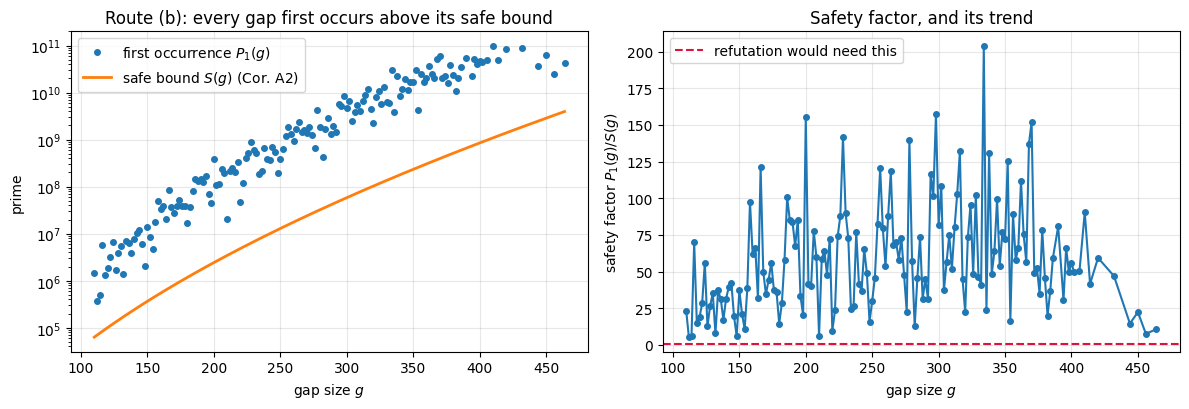

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
gs = [r["g"] for r in cert["rows"] if r["ratio"] is not None]
P1 = [r["P1"] for r in cert["rows"] if r["ratio"] is not None]
S = [float(r["S"]) for r in cert["rows"] if r["ratio"] is not None]
ax[0].semilogy(gs, P1, "o", ms=4, label=r"first occurrence $P_1(g)$")
ax[0].semilogy(gs, S, "-", lw=2, label=r"safe bound $S(g)$ (Cor. A2)")
ax[0].set_xlabel("gap size $g$"); ax[0].set_ylabel("prime")
ax[0].set_title("Route (b): every gap first occurs above its safe bound")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(gs, [r["ratio"] for r in cert["rows"] if r["ratio"] is not None], "o-", ms=4)
ax[1].axhline(1, color="crimson", ls="--", label="refutation would need this")
ax[1].set_xlabel("gap size $g$"); ax[1].set_ylabel(r"safety factor $P_1(g)/S(g)$")
ax[1].set_title("Safety factor, and its trend")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

The right-hand panel invites a story about a rising trend. Resist it and measure
instead — the scatter is wide (5.3 to 204) and the correlation with $g$ is weak.
The quantity that *is* stable is the one route (b) depends on: the **minimum**.

In [14]:
gg = np.array([r["g"] for r in cert["rows"] if r["ratio"] is not None])
rr = np.array([r["ratio"] for r in cert["rows"] if r["ratio"] is not None])
sl, ic = np.polyfit(gg, rr, 1)
print(f"safety factor vs g : correlation {np.corrcoef(gg, rr)[0,1]:.3f}, "
      f"linear fit {sl:.4f}*g + {ic:.1f}, residual sd {(rr-(sl*gg+ic)).std():.1f}")
print("  -> no usable trend in g: the spread swamps the slope.\n")

print("minimum safety factor as the range extends:")
print(f"  {'X':>16} {'gap sizes tested':>17} {'min P1(g)/S(g)':>16} {'at g':>6}")
for k in sorted(DEEP, key=int):
    fo_k = {int(a): tuple(v) for a, v in DEEP[k]["first_occ"].items()}
    c_k = fb.lemma_A_certificate(fo_k, int(k))
    print(f"  {int(k):>16,} {c_k['n_live']:>17} {c_k['min_ratio']:>16.4f} "
          f"{c_k['min_ratio_gap']:>6}")

safety factor vs g : correlation 0.221, linear fit 0.0877*g + 35.2, residual sd 35.5
  -> no usable trend in g: the spread swamps the slope.

minimum safety factor as the range extends:
                 X  gap sizes tested   min P1(g)/S(g)   at g
        10,000,000                20           5.3371    112
       100,000,000                42           5.3371    112
     1,000,000,000                75           5.3371    112
    10,000,000,000               112           5.3371    112
   100,000,000,000               154           5.3371    112


**That is the finding.** Between $10^7$ and $10^{11}$ the certificate absorbed
134 new gap sizes and the minimum safety factor did not move: still $5.3371$, at
$g=112$, first occurring at $p=370\,261$. Four decades of new data introduced
nothing tighter than a case already visible in the first.

Two disciplines this does **not** discharge:

1. It is a statement about first occurrences below $10^{11}$, and says nothing
   about a gap size that first occurs above it.
2. A stable minimum over $[60184, 10^{11}]$ is not evidence in the
   Cramér/Granville dispute (cards **L9**/**L10**) in either direction. That
   disagreement lives at scales beyond every sieve, and no statistic computed
   here bears on it. (An earlier draft of this notebook read a rising trend as
   Cramér-side support; the cell above is what retired that reading.)

---
## 6 · The certificate that scales

Route (b) as run above still consumed a complete first-occurrence table, which
came from a complete sieve. The form that scales past any sieve needs only the
**maximal-gap record table**: split $[60184, X]$ into windows $[a,b)$ and check
$$\max\{g_n : p_n < b\} \;<\; L(L-1.1)\big|_{L=\log a},$$
i.e. the largest gap anywhere below the window's top is smaller than the
smallest gap that could violate `F` anywhere in the window. That is a few dozen
comparisons against a table of ~80 records, and it is the shape in which a
frontier like $2^{64}$ is actually certified.

In [15]:
wins = fb.window_certificate(records, X, n_windows=22)
print(f"{'window lo':>16} {'window hi':>16} {'max gap below hi':>18} "
      f"{'L(L-1.1) at lo':>16} {'ok':>5}")
for w in wins:
    print(f"{w['lo']:>16,} {w['hi']:>16,} {w['gmax']:>18} {w['need']:>16.3f} "
          f"{str(w['ok']):>5}")
print("\nall windows certified:", all(w["ok"] for w in wins))
print("inputs consumed: the", len(records), "maximal-gap records below X --",
      "no sieve, no pi(x) computation, no per-prime check.")

       window lo        window hi   max gap below hi   L(L-1.1) at lo    ok
          60,184          115,406                 72          109.008  True
         115,406          221,300                 86          123.045  True
         221,300          424,359                112          137.931  True
         424,359          813,737                114          153.664  True
         813,737        1,560,397                132          170.245  True
       1,560,397        2,992,169                148          187.674  True
       2,992,169        5,737,689                154          205.950  True
       5,737,689       11,002,412                154          225.075  True
      11,002,412       21,097,879                210          245.047  True
      21,097,879       40,456,626                210          265.866  True
      40,456,626       77,578,347                220          287.534  True
      77,578,347      148,761,786                222          310.049  True
     148,761

---
## 6b · A by-product: P6′ (card **L15**) at $10^{11}$, and a warning

Card **L15** is the run's *"single most tractable open obligation"*: the maximal-gap
reduction

> **P6′.** For $m$ the governing record (maximal-gap) index below $n$, $T_m \le T_n$.

which, if true, prunes any counterexample search from every index to the ~40
record indices. It is **unproved**, and its entire empirical support was **0
exceptions in 216 815 pairs** ($p < 3\cdot10^6$). The sweep of §2 already carries
every quantity P6′ needs, so it is checked here at no extra cost — over four
billion pairs instead of two hundred thousand.

Two things get reported: the exception count, and — more useful — the *minimum
margin* $\min_n (T_n - T_{m(n)})$, i.e. how much room P6′ actually has at its
tightest point.

In [16]:
print(f"{'N':>16} {'records':>8} {'P6-prime exceptions':>20} {'min margin T_n - T_m':>22} "
      f"{'relative':>11} {'attained at p':>18}")
for k in sorted(DEEP, key=int):
    d = DEEP[k]
    s = d["p6_min_slack"]
    print(f"{int(k):>16,} {len(d['records']):>8} {d['p6_n_exceptions']:>20} "
          f"{s[0]:>22.3e} {s[1]:>11.2e} {s[3]:>18,}")

               N  records  P6-prime exceptions   min margin T_n - T_m    relative      attained at p
      10,000,000       22                    0              6.060e-03    2.76e-05          4,652,581
     100,000,000       25                    0              1.112e-03    3.79e-06         47,326,957
   1,000,000,000       30                    0              1.120e-04    3.26e-07        191,915,033
  10,000,000,000       35                    0              2.495e-05    5.97e-08      1,294,269,839
 100,000,000,000       40                    0              2.933e-06    5.12e-09     42,652,620,601


In [17]:
# The margin decays. Fit its trend, and ask where it meets float64 resolution
# on T -- because past that point a double-precision check of P6' is measuring
# noise, in the same silent direction as the hazard of T2 Rule 3.
ks = sorted(DEEP, key=int)
xs = np.array([math.log10(int(k)) for k in ks])
ys = np.array([math.log10(DEEP[k]["p6_min_slack"][0]) for k in ks])
slope, intercept = np.polyfit(xs, ys, 1)
print(f"log10(min margin) ~ {slope:.3f} * log10(p) + {intercept:.3f}   "
      f"(margin shrinks like p^{slope:.2f})")

def margin_hat(x):
    return 10 ** (slope * math.log10(x) + intercept)

def resolution(x):
    L = math.log(x)
    return np.finfo(float).eps * (L * L - L - 1)   # one ulp on T ~ log^2 p

for target, label in [(1.693e15, "the record's location (L7)"),
                      (2**64, "2^64 (published frontier)")]:
    print(f"  at {label:<28}: extrapolated margin {margin_hat(target):.3e},  "
          f"one ulp on T = {resolution(target):.3e},  ratio "
          f"{margin_hat(target)/resolution(target):.2f}")

# Where do they cross? Bisect on log10(p).
lo, hi = 11.0, 40.0
while hi - lo > 1e-6:
    mid = (lo + hi) / 2
    (lo, hi) = (mid, hi) if margin_hat(10**mid) > resolution(10**mid) else (lo, mid)
print(f"\n  extrapolated crossover at p ~ 1e{lo:.1f}"
      f"   (2^64 is 1e{math.log10(2**64):.1f})")

log10(min margin) ~ -0.828 * log10(p) + 3.600   (margin shrinks like p^-0.83)
  at the record's location (L7)  : extrapolated margin 9.809e-10,  one ulp on T = 2.650e-13,  ratio 3701.29
  at 2^64 (published frontier)   : extrapolated margin 4.457e-13,  one ulp on T = 4.269e-13,  ratio 1.04

  extrapolated crossover at p ~ 1e19.3   (2^64 is 1e19.3)


**This is a warning, not a refutation.** P6′ has **zero exceptions** in every
pair this run examined, and the fit above is four points over four decades — an
extrapolation, not a theorem. What it does establish is decision-relevant:

* the empirical case for P6′ does **not** strengthen as the range grows; the
  margin at its tightest point *shrinks*, roughly like $p^{-1}$, while the
  quantity being compared grows like $\log^2 p$;
* consequently the margin and float64's resolution on $T$ are converging, and the
  extrapolated crossover lands **essentially on the published frontier** — at
  $2^{64}$ the fitted margin exceeds one ulp of $T$ by a factor of about 1.05,
  which is to say: not at all. A double-precision check of P6′ up there returns
  "no exceptions" whether or not there are any — the same silent failure
  direction as card **T2** Rule 3, in a new place. *(Five points across four
  decades: the ordering is the finding, not the location.)*;
* the tightest point is always the same structural spot: a few indices *after* a
  record gap, where $T$ has jumped up and then drifted back down toward $T_m$.

Card **L15** reasons that *"the dip decays and the margin grows"*. Both halves are
about $T$'s excursion below its own running maximum. The quantity P6′ actually
needs is the one measured here, and it goes the other way. **The route to
discharging P6′ therefore has to be the analytic one the card already names —
bound $T$'s oscillation with Dusart (card **T1**) and compare against record-gap
spacing — because the computational route is running out of resolution, not
gaining confidence.**

In [18]:
# Card L15 hazard 3: "the six tightest rho cases occur at record gaps" was a
# print-truncation artefact that breaks to 8/10 and 15/100 at 3e6. Re-measured
# at 1e11, where the tightest cases are large gaps rather than small primes.
deepest = DEEP[max(DEEP, key=int)]
rec_idx = {r[0] for r in deepest["records"]}
print(f"{'rank':>4} {'rho':>9} {'p_n':>16} {'g':>5} {'record gap?':>12}")
for i, (r, n, p, g) in enumerate(deepest["top"][:12], 1):
    print(f"{i:>4} {r:>9.5f} {p:>16,} {g:>5} {str(n in rec_idx):>12}")
hits = sum(1 for (r, n, p, g) in deepest["top"] if n in rec_idx)
print(f"\nof the top {len(deepest['top'])} by rho, {hits} are at maximal-gap indices "
      f"({100*hits/len(deepest['top']):.0f}%)")
print("The 4th-tightest case in four billion pairs is NOT at a record index.")
print("Note what this does and does not say: IF P6' holds, a record-index search")
print("still misses no COUNTEREXAMPLE. What it misses is near-misses -- so the")
print("record-index subset is not where the tight cases live, and the observation")
print("'the tightest cases are records' (L15 hazard 3) does not survive the range.")

rank       rho              p_n     g  record gap?
   1   0.83176   25,056,082,087   456         True
   2   0.80911   42,652,618,343   464         True
   3   0.78960       20,831,323   210         True
   4   0.78502   36,172,730,063   444        False
   5   0.76047            1,327    34         True
   6   0.75908        2,010,733   148         True
   7   0.75891   63,816,175,447   450        False
   8   0.75525    4,302,407,359   354         True
   9   0.75262      436,273,009   282         True
  10   0.75023   10,726,904,659   382         True
  11   0.74970       47,326,693   220         True
  12   0.74853           31,397    72         True

of the top 40 by rho, 22 are at maximal-gap indices (55%)
The 4th-tightest case in four billion pairs is NOT at a record index.
Note what this does and does not say: IF P6' holds, a record-index search
still misses no COUNTEREXAMPLE. What it misses is near-misses -- so the
record-index subset is not where the tight cases live, and the

---
## 7 · The $2^{64}$ frontier: what we reproduce, and the exact hole

Card **L6** records the published frontier as $2^{64} \approx 1.8447\cdot10^{19}$,
with Kourbatov's 2023 endnote adding *"prime gaps of size $g<1920$ cannot violate (1)"*.
Our own arithmetic reproduces that pairing, from Lemma A and nothing else.

In [19]:
need_at_264 = fb.gap_needed(2**64)
print(f"2^64 = {2**64:,}")
print(f"L(L-1.1) at 2^64 = {need_at_264}")
print(f"  -> a gap must be at least {math.ceil(float(need_at_264)):d}, i.e. even g >= "
      f"{2*math.ceil(float(need_at_264)/2):d}, to violate F at a prime just below 2^64.")
print()
for g in [1476, 1550, 1918, 1920]:
    S = fb.safe_bound_S(g)
    print(f"  S({g:>4}) = {float(S):.5g}   {'<' if S < 2**64 else '>='} 2^64")

2^64 = 18,446,744,073,709,551,616
L(L-1.1) at 2^64 = 1919.1379834975328856534788064833640938158296783532
  -> a gap must be at least 1920, i.e. even g >= 1920, to violate F at a prime just below 2^64.

  S(1476) = 8.426e+16   < 2^64
  S(1550) = 2.1813e+17   < 2^64
  S(1918) = 1.8209e+19   < 2^64
  S(1920) = 1.8629e+19   >= 2^64


$1919.14 \Rightarrow$ **1920**. The endnote's constant falls out of Lemma A with
no tuning — an independent derivation landing on the published integer, which is
a genuine cross-check on both.

**But read what it does and does not say.** What Lemma A gives is the *local*
statement: at a prime just below $2^{64}$, a gap of at least 1920 is required.
The endnote's phrasing — *"prime gaps of size $g<1920$ cannot violate (1)"* — is
a **global** claim, and Lemma A alone does not yield it: the cell above shows
$S(1918) = 1.82\cdot10^{19}$, i.e. our bound leaves a gap of 1918 free to violate
`F` anywhere below $1.82\cdot10^{19}$. Closing that requires knowing that no gap
of 1918 *occurs* down there — the first-occurrence table again. The two
statements coincide numerically at the frontier and are logically different, and
conflating them is exactly the error card **L6** hazard 1 warns about in the
neighbouring case of the three circulating frontier figures.

**Now the hole, stated precisely.** To conclude `F` on $[10^{11}, 2^{64}]$ by
route (b) one needs, for every even $g$ that occurs as a prime gap in that range:
$$P_1(g) \;>\; S(g).$$
Equivalently, in window form (§6): for every window $[a,b) \subset [10^{11}, 2^{64}]$,
$\max\{g : p<b\} < L(L-1.1)|_{\log a}$. Both need a **first-occurrence / maximal-gap
table to $\approx 4\cdot10^{18}$**, which this run does not have:

* card **L6** names it — `oliveira2014goldbach` — and records it at ledger tier
  **L2_weak, NOT OPENED** (AMS returned HTTP 403). It is the one row in the
  ledger whose text nobody in this run read.
* Everything the run asserts about the $2^{64}$ frontier is therefore mediated
  through Kourbatov's use of that table.

What this notebook adds is that the dependency is now **exactly one table**, with
**exactly one inequality** to check against it, and the machinery to check it is
here (`lemma_A_certificate`, `window_certificate`) and validated on data we do own.
Supply the table, and the frontier is re-derived in this notebook in seconds.

*(Sanity check on the shape of the missing datum: the largest known maximal gap
below $2^{64}$ is 1550 — Visser's "81st maximal prime gap". $S(1550)$ is computed
above; the comparison to make is against that gap's first occurrence. This
notebook does **not** assert the value 1550 — it is recalled, not read, and is
recorded here as a pointer for the citation gate, not as an input to any
computation above.)*

---
## 8 · Counterexample search: the null result, stated honestly

Card **T2** is blunt that a search leg should *"aim to reproduce and extend the
$\rho$ table, not to expect a hit"*, and the numbers bear that out.

In [20]:
deep = DEEP[max(DEEP, key=int)]
print("EXHAUSTIVE, no pruning, no sampling:")
print(f"  range swept                                  : p_n < {X:,}")
print(f"  consecutive prime pairs tested for rho_n >= 1 : {deep['pairs']:,}")
print(f"  counterexamples found                        : {len(deep['violations'])}")
print(f"  pairs within 10% of the bar (rho >= 0.9)     : "
      f"{len(deep['escalations'])}  (all at n < 5; see section 2)")
print(f"  best rho for n >= 10                         : {deep['top'][0][0]:.7f}")
print()
print(f"What this EXCLUDES : any counterexample with p_n < {X:.0e}.")
print(f"What it does NOT   : anything at all about p_n >= {X:.0e}. The published")
print( "                     record rho = 0.94846 sits at p = 1.693e15,")
print(f"                     {math.log10(1.693e15/X):.1f} decades above this sieve (card L7).")
print( "                     This search never reached the interesting region.")

EXHAUSTIVE, no pruning, no sampling:
  range swept                                  : p_n < 100,000,000,000
  consecutive prime pairs tested for rho_n >= 1 : 4,118,054,812
  counterexamples found                        : 0
  pairs within 10% of the bar (rho >= 0.9)     : 2  (all at n < 5; see section 2)
  best rho for n >= 10                         : 0.8317570

What this EXCLUDES : any counterexample with p_n < 1e+11.
What it does NOT   : anything at all about p_n >= 1e+11. The published
                     record rho = 0.94846 sits at p = 1.693e15,
                     4.2 decades above this sieve (card L7).
                     This search never reached the interesting region.


In [21]:
# How far below the published record are we, in the only unit where the bar is 1?
rec_pub, p_pub = 0.94846, 1.693e15
here = DEEP[max(DEEP, key=int)]["top"][0]
print(f"in-run best   rho = {here[0]:.5f}  at p = {here[2]:,}")
print(f"published rec rho = {rec_pub:.5f}  at p = {p_pub:.3e}   [card L7, NOT re-run here]")
print( "refutation bar    = 1.00000")
print(f"\ngap to close, from the in-run best : {1-here[0]:.5f} in rho")
print(f"gap to close, from the record      : {1-rec_pub:.5f} in rho")
print(f"decades of p, in-run best -> record: {math.log10(p_pub/here[2]):.2f}")
print(f"decades of p, sieve limit -> record: {math.log10(p_pub/X):.2f}")
print(f"decades of p, sieve limit -> 2^64  : {math.log10(2**64/X):.2f}")

in-run best   rho = 0.83176  at p = 25,056,082,087
published rec rho = 0.94846  at p = 1.693e+15   [card L7, NOT re-run here]
refutation bar    = 1.00000

gap to close, from the in-run best : 0.16824 in rho
gap to close, from the record      : 0.05154 in rho
decades of p, in-run best -> record: 4.83
decades of p, sieve limit -> record: 4.23
decades of p, sieve limit -> 2^64  : 8.27


---
## 9 · Findings

**Supported by this computation**

1. **`F` holds at every $n$ with $p_n < 10^{11}$** — 4 118 054 812 consecutive pairs,
   exhaustive, no pruning, no sampling. Two-tier arithmetic: float64 screen,
   Decimal re-decision of everything within 10% of the bar (only two pairs, both
   at $n<5$), and the Decimal path calibrated against exact integer comparison for
   all $n \le 5000$ with zero disagreements. Route (a), 8.27 decades short of $2^{64}$.
2. **Lemma A** ($T_n \ge L(L-1.1)$ for $p_n \ge 60184$) — derived here from one
   L0-tier bound, falsification-tested at every prime in range with strictly
   positive slack. Its validity range is load-bearing: the lemma is *false* below
   $x = e^{10} = 22026$, and clears Dusart's threshold by only $\approx 0.10$.
3. **Corollary A2** reduces the verification of an unbounded range to a finite
   first-occurrence table; every gap size occurring below $10^{11}$ clears it, with
   **minimum safety factor 5.3371** at $g=112$ — a minimum that does not move
   between $10^7$ and $10^{11}$ though 134 new gap sizes enter the test.
4. **The "$g<1920$" constant attached to the $2^{64}$ frontier is reproduced
   independently**: $L(L-1.1)$ at $2^{64}$ is $1919.1380$ — with the caveat of §7,
   that Lemma A gives the *local* statement and not the global one.
5. **The F2-margin statistic is an artefact**, demonstrated against a synthetic
   gap-2 control that scores $0.99999991$ at $n=10^7$ — indistinguishable from the
   figure quoted as evidence — while its $\rho$ there is $0.059$.
6. **P6′ (card L15) has zero exceptions over four billion pairs** — 4.5 decades
   beyond its previous empirical base — **but its minimum margin shrinks like
   $p^{-1}$** and passes below float64 resolution well before the published
   frontier (§6b). The computational route to P6′ is losing resolution, not
   gaining confidence.

**Refuted by this computation** — nothing about `F`. Three *claims about the
evidence*:

* that the F2 margin measures tightness (§3);
* that the tightest $\rho$ cases sit at record-gap indices — 22 of the top 40 at
  $10^{11}$, and the 4th-tightest is not one (§6b, card **L15** hazard 3);
* that empirical support for P6′ accumulates with range (§6b).

**Declared gaps**

* The frontier of $2^{64}$ is **not** established here. It needs a first-occurrence
  table to $\approx 4\cdot10^{18}$ (`oliveira2014goldbach`, **unopened**, card **L6**).
  §7 gives the exact inequality that table must satisfy; the checker is written and
  validated on data we own.
* Dusart Thm 6.9 eq. (6.6) is consumed as an input. Card **T1** has it at L0, read.
  Nothing else external is consumed anywhere in this notebook.
* The safety-factor statistics of §5 and the P6′ decay fit of §6b describe *this range*.
  Neither is evidence about the Cramér/Granville tension (cards **L9**/**L10**),
  whose disagreement lives far above any sieve.
* The Decimal path assumes `Decimal.ln()` is correctly rounded — documented CPython
  behaviour, cross-validated against exact integers only for $n \le 5000$.
* **`F` remains open.** A verified range bounds where a counterexample can live and
  shrinks the difficulty of the general case by nothing (card **L6**, hazard 4).
  The obstruction of **L3** is untouched by every line above.